<a href="https://colab.research.google.com/github/Tejaswanirongali/my-first-reposs/blob/main/fake_social_media_profile_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
data = pd.read_excel("/content/fake social media detection code.xlsx")

In [ ]:
print(data.columns)
X = data.drop(["behavior", "_id", "Unnamed: 0"], axis=1) # Drop target, _id, and Unnamed: 0
y = data["behavior"]

# Identify categorical columns for one-hot encoding
categorical_cols = X.select_dtypes(include='object').columns

# Apply one-hot encoding
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

Index(['Unnamed: 0', '_id', 'inter_api_access_duration(sec)',
       'api_access_uniqueness', 'sequence_length(count)',
       'vsession_duration(min)', 'ip_type', 'behavior', 'behavior_type',
       'num_sessions', 'num_users', 'num_unique_apis', 'source'],
      dtype='object')


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model = LogisticRegression()

In [ ]:
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.953125

Confusion Matrix:
 [[  0   0   0   0   0   0   0   0   0   0   1]
 [  0   1   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   1]
 [  0   0   0   0   1   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   1]
 [  0   0   0   0   0   0   0   0   0   0   3]
 [  0   0   0   0   0   0   0   0   0   0   1]
 [  0   0   0   0   0   0   0   0   2   0   0]
 [  0   0   0   0   0   0   0   0   0   0   1]
 [  0   0   0   0   0   0   0   0   0   0 180]]

Classification Report:
                                             precision    recall  f1-score   support

                             AdsBot-Google       0.00      0.00      0.00         1
                          BingPreview/1.0b       1.00      1.00      1.00         1
BingPreview/1.0b;Mobile Safari;bingbot/2.0       0.00      0.00      0.00         1
              BingPreview/1.0b;bingbot/2.0       0.00      0.00      0.00        

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

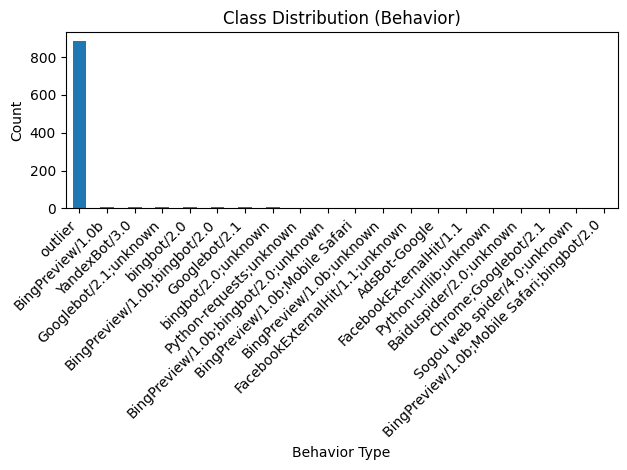

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
y.value_counts().plot(kind='bar')
plt.title("Class Distribution (Behavior)")
plt.xlabel("Behavior Type")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

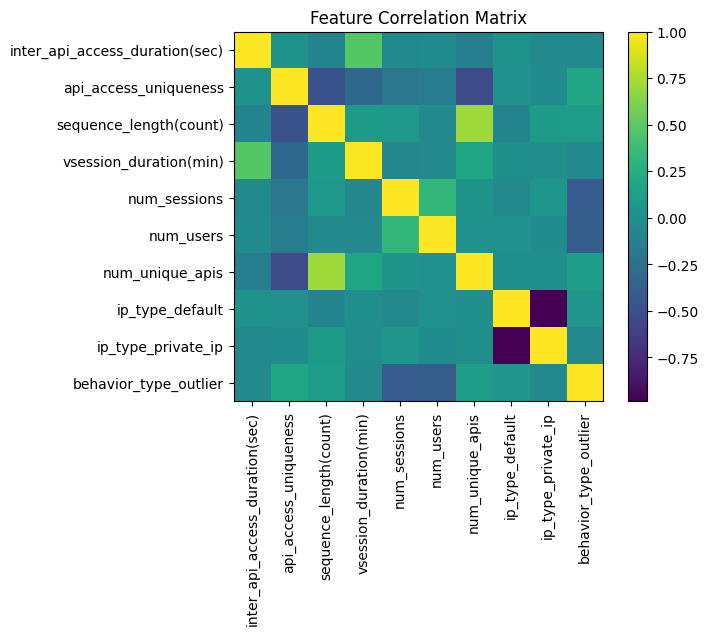

In [ ]:
plt.figure()
correlation_matrix = X.corr()

plt.imshow(correlation_matrix)
plt.title("Feature Correlation Matrix")
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.colorbar()
plt.show()

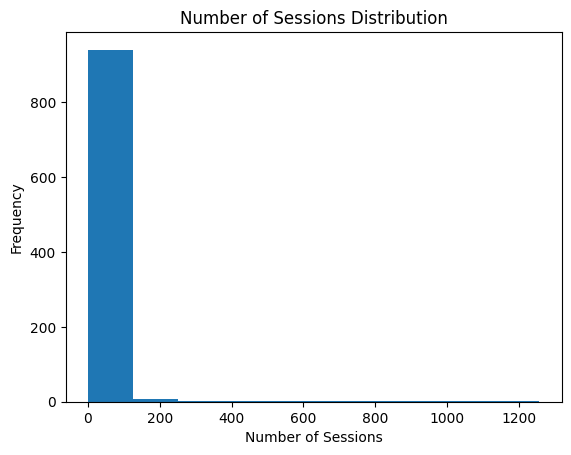

In [ ]:
plt.figure()
plt.hist(data['num_sessions'])
plt.title("Number of Sessions Distribution")
plt.xlabel("Number of Sessions")
plt.ylabel("Frequency")
plt.show()

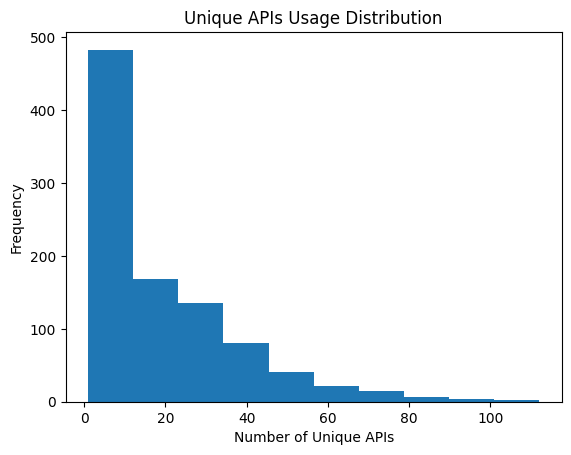

In [ ]:
plt.figure()
plt.hist(data['num_unique_apis'])
plt.title("Unique APIs Usage Distribution")
plt.xlabel("Number of Unique APIs")
plt.ylabel("Frequency")
plt.show()